# Multi-Feature Linear Regression

This notebook uses `MultiFeatureProfit.csv` (2 features: **Population**, **MedianIncome**) to train a multi-feature linear regression with **scikit-learn**.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## 1. Load & Explore the Data

In [13]:
df = pd.read_csv("MultiFeatureProfit.csv")
print(f"Shape: {df.shape}")
print()
df.describe()

Shape: (97, 3)



,Population,MedianIncome,Profit
count,97.000000,97.000000,97.000000
mean,8.159800,6.178016,5.839135
std,3.869884,1.671660,5.510262
min,5.026900,2.915000,-2.680700
25%,5.707700,4.959600,1.986900
50%,6.589400,5.890100,4.562300
75%,8.578100,7.045200,7.046700
max,22.203000,11.647800,24.147000


## 2. Visualise the Data

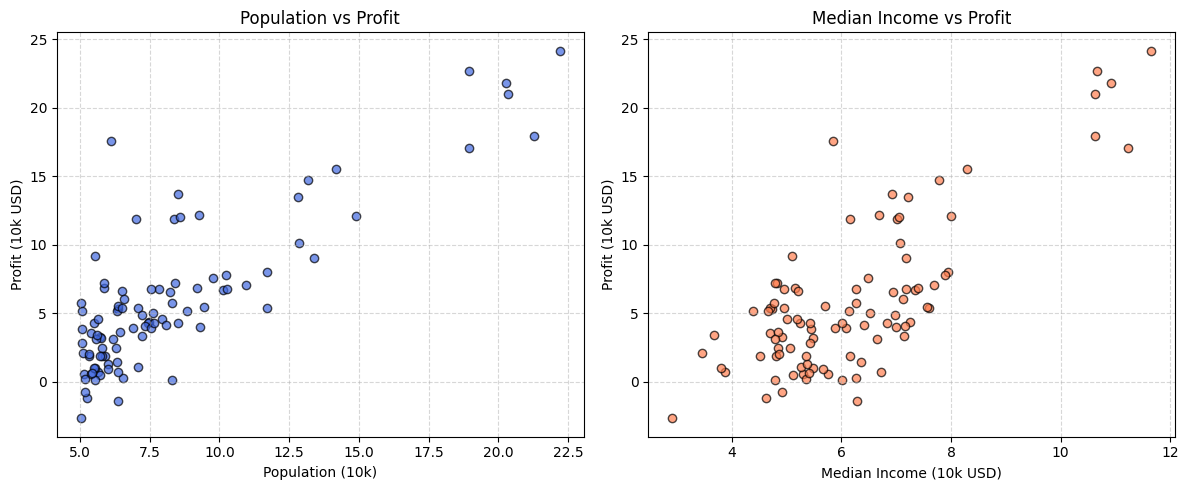

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["Population"], df["Profit"], c="royalblue", edgecolors="k", alpha=0.7)
axes[0].set_xlabel("Population (10k)")
axes[0].set_ylabel("Profit (10k USD)")
axes[0].set_title("Population vs Profit")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].scatter(df["MedianIncome"], df["Profit"], c="coral", edgecolors="k", alpha=0.7)
axes[1].set_xlabel("Median Income (10k USD)")
axes[1].set_ylabel("Profit (10k USD)")
axes[1].set_title("Median Income vs Profit")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Feature Correlation

In [15]:
corr = df.corr()
print(corr.to_string())

              Population  MedianIncome    Profit
Population      1.000000      0.897985  0.837873
MedianIncome    0.897985      1.000000  0.770033
Profit          0.837873      0.770033  1.000000


## 4. Train/Test Split & Feature Scaling

In [6]:
X = df[["Population", "MedianIncome"]].values
y = df["Profit"].values
feature_names = ["Population", "MedianIncome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples:     {X_test_scaled.shape[0]}")

Training samples: 77
Test samples:     20


## 5. Train Multi-Feature Linear Regression

In [7]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"Intercept (theta_0): {model.intercept_:.4f}")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name:<15s}  theta = {coef:+.4f}")

Intercept (theta_0): 5.7463
  Population       theta = +4.2169
  MedianIncome     theta = +0.5621


## 6. Model Evaluation

In [9]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

metrics = {
    "Metric": ["R2", "MSE", "RMSE", "MAE"],
    "Train": [
        r2_score(y_train, y_train_pred),
        mean_squared_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        mean_absolute_error(y_train, y_train_pred),
    ],
    "Test": [
        r2_score(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_error(y_test, y_test_pred),
    ],
}

pd.DataFrame(metrics).set_index("Metric")

,Train,Test
Metric,,
R2,0.753492,0.501969
MSE,7.308245,15.658270
RMSE,2.703377,3.957053
MAE,2.126255,2.544428


## 7. Actual vs Predicted

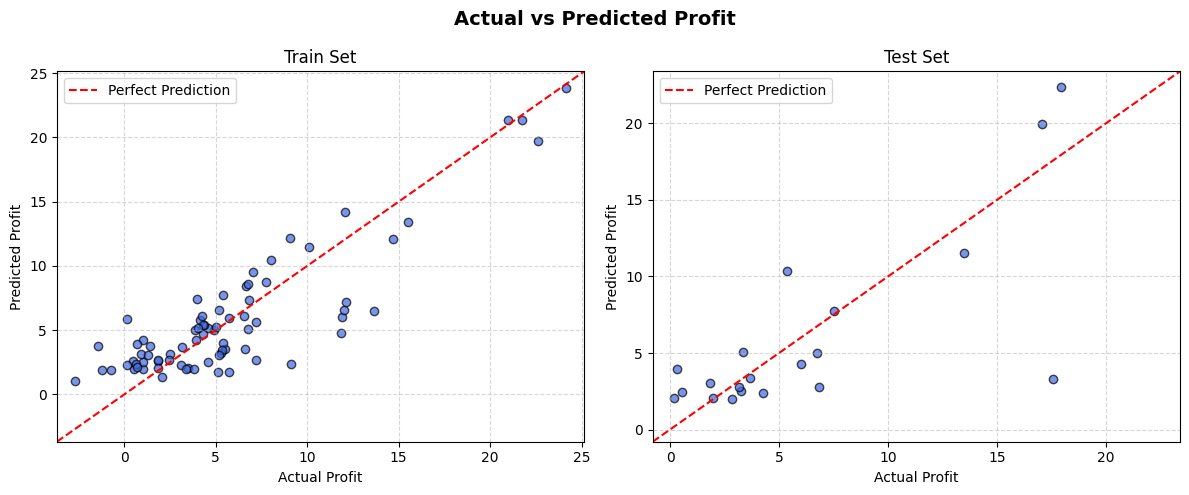

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_train_pred, "Train"),
    (axes[1], y_test, y_test_pred, "Test"),
]:
    ax.scatter(y_true, y_pred, c="royalblue", edgecolors="k", alpha=0.7)
    lims = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual Profit")
    ax.set_ylabel("Predicted Profit")
    ax.set_title(f"{title} Set")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Actual vs Predicted Profit", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Predict on New Data Points

In [11]:
# New data: [Population, MedianIncome]
new_data = np.array([
    [5.0,  4.5],
    [10.0, 6.5],
    [15.0, 8.0],
    [20.0, 9.5],
])

new_data_scaled = scaler.transform(new_data)
new_preds = model.predict(new_data_scaled)

result = pd.DataFrame(new_data, columns=feature_names)
result["Predicted Profit"] = np.round(new_preds, 4)
result

,Population,MedianIncome,Predicted Profit
0,5.0,4.5,1.5792
1,10.0,6.5,8.0164
2,15.0,8.0,14.2822
3,20.0,9.5,20.5481
